--- Initializing VP-SDE ---
Running demonstration for VP-SDE...


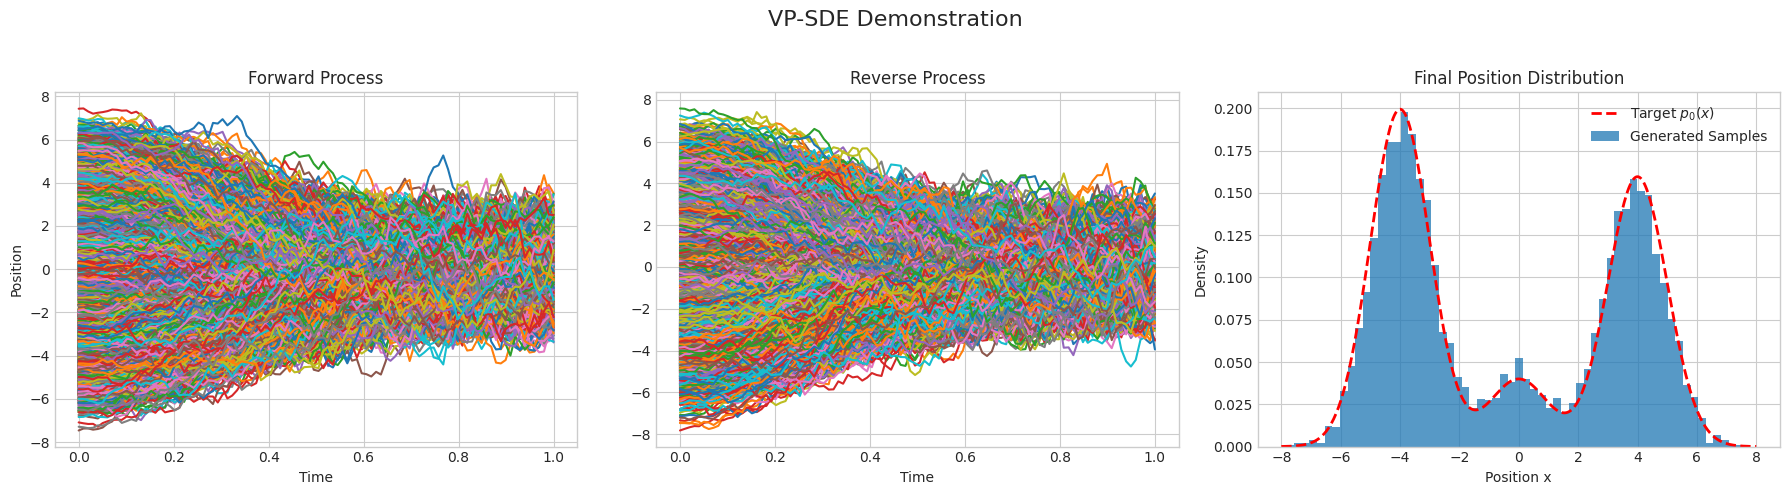

--- Initializing Critically Damped Langevin ---
Pre-computing Critically Damped Langevin analytical mean propagator...
Running demonstration for Critically Damped Langevin...
Solving forward SDE for Critically Damped Langevin...


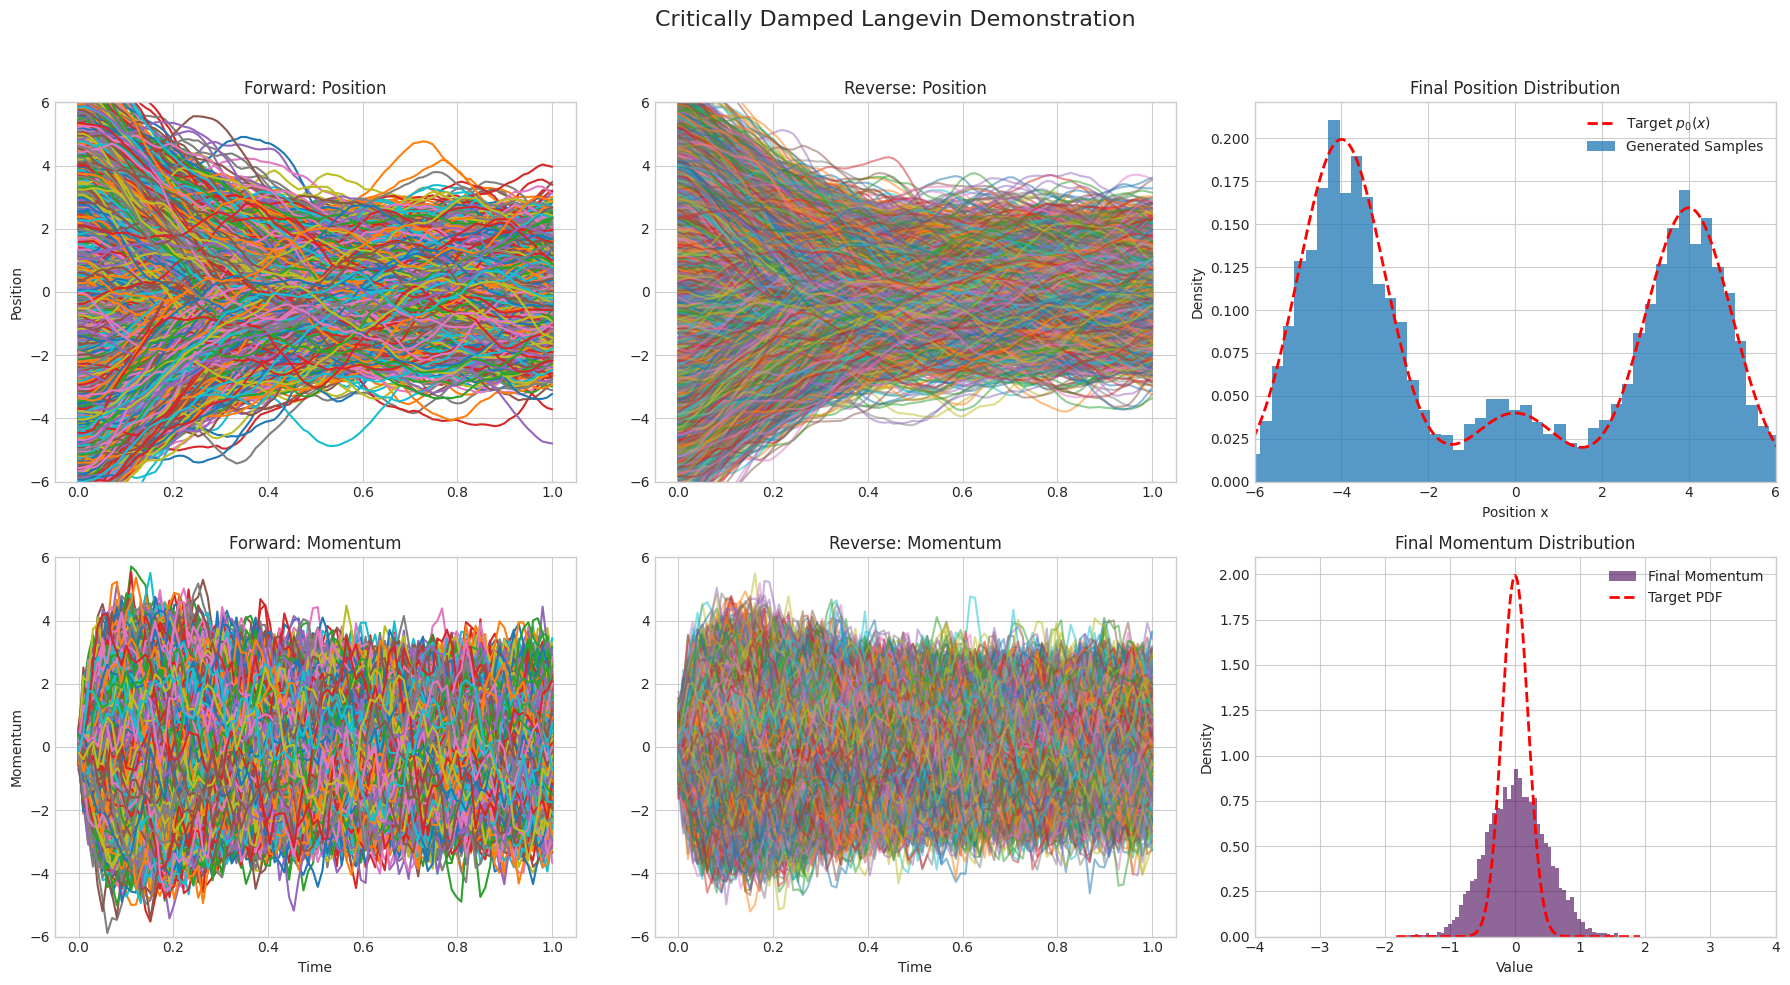



--- Initializing Generalized Langevin Diffusion ---
Precomputing perturbation kernels analytically...
Precomputation finished.

Running demonstration for Generalized Langevin Diffusion...
Solving forward SDE for Generalized Langevin Diffusion...
Precomputing for SSCS sampler...
SSCS precomputation finished.
Solving reverse SDE for Generalized Langevin Diffusion with SSCS...


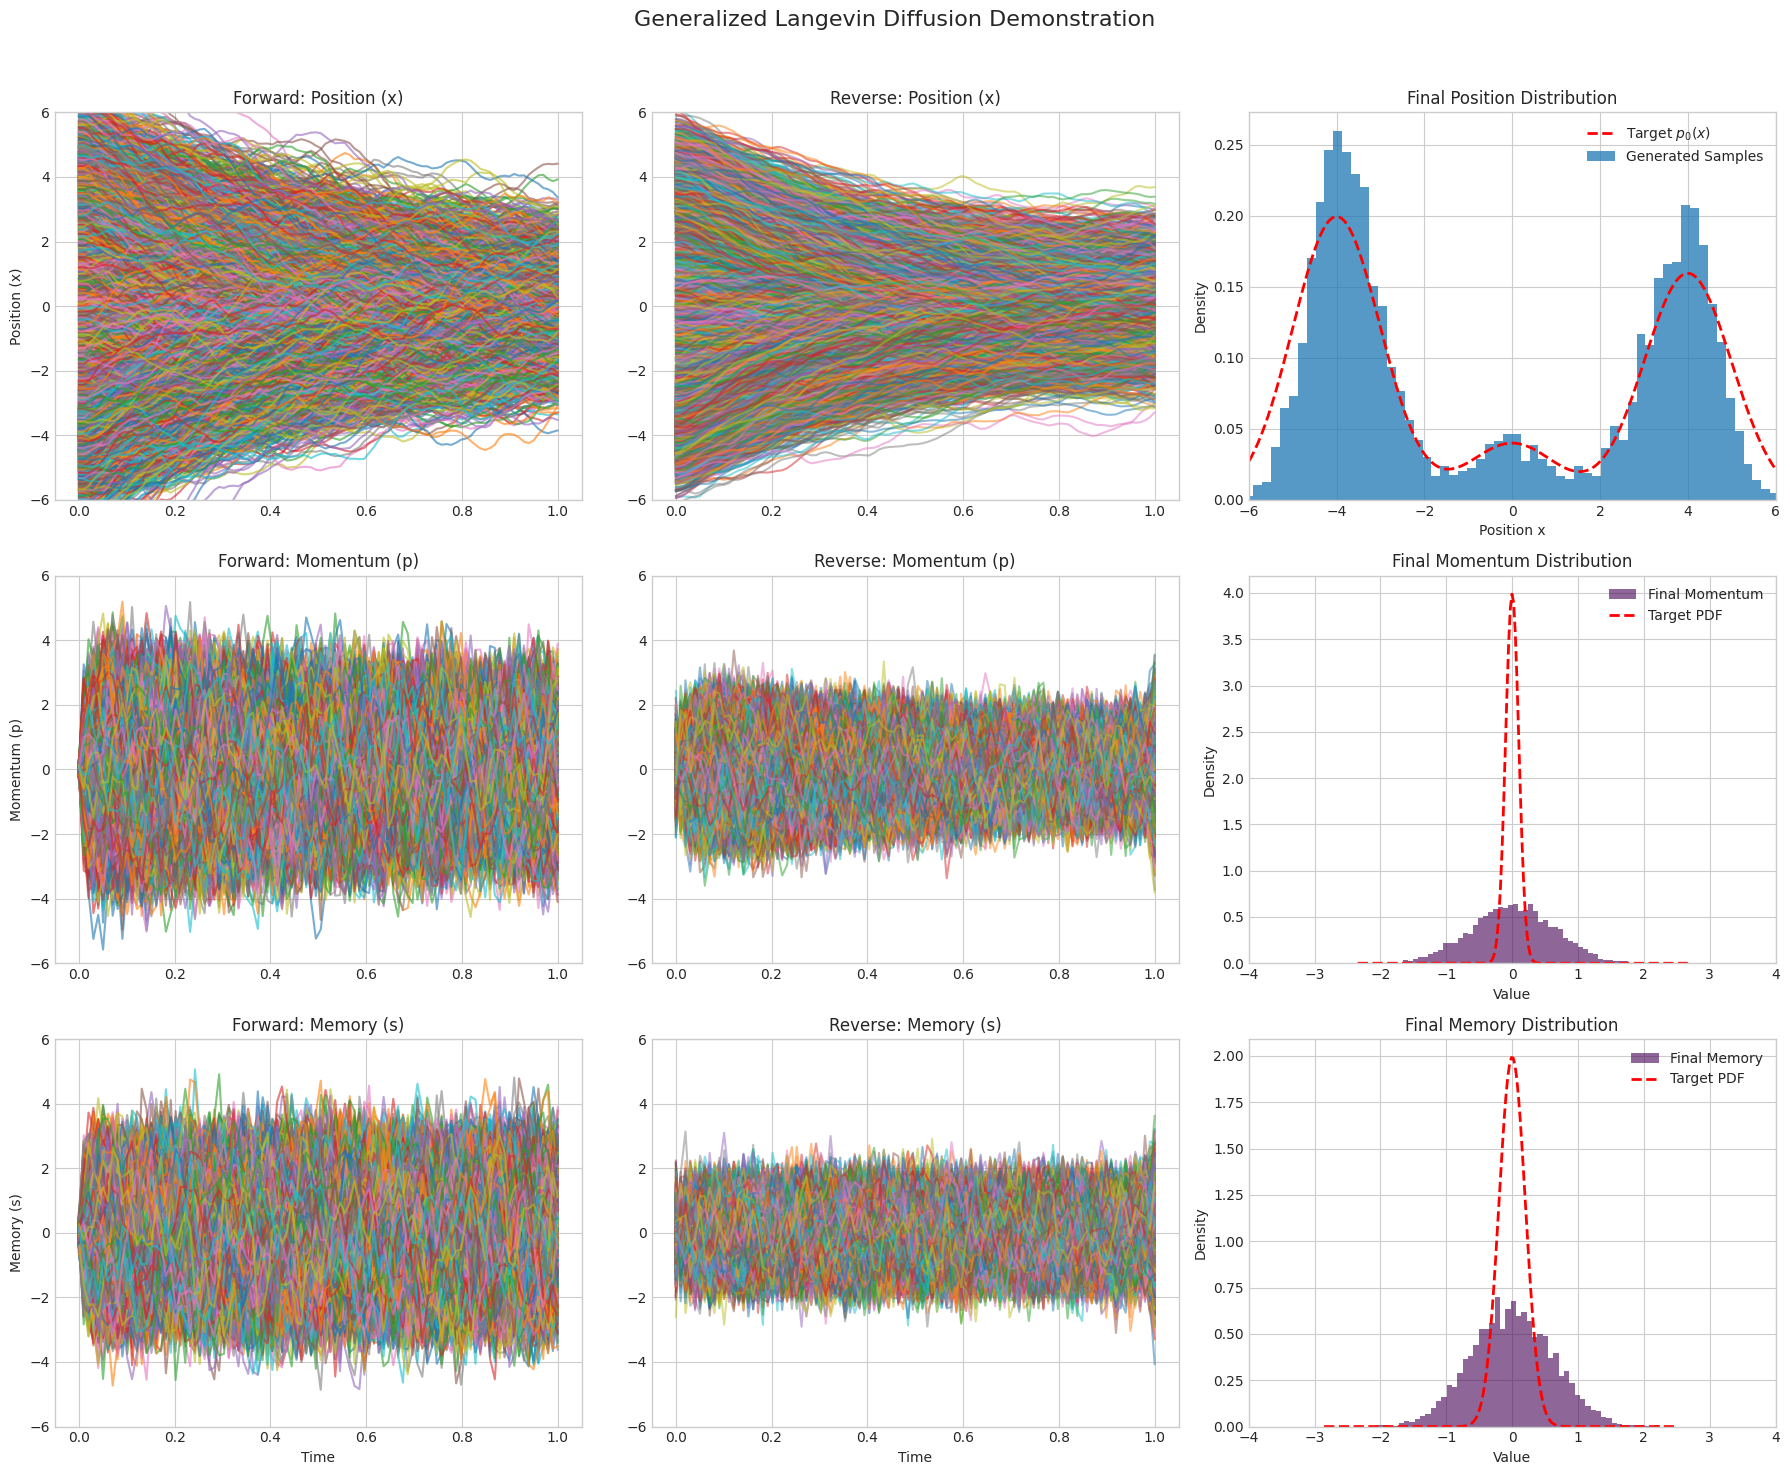

In [ ]:
# Questions:
# Why aren't momentum and memory distributions lining up?
# Implement Matthias perturbation kernel.
# Cache the covariance integration in matrix_exp if possible. 
# Implement PFODE with inbuilt solver
# Fix GLD numerical error outlier.
# Simulate forward exactly.
# Why is the SSCS reverse so skinny? 
# Same color alpha = 0.05, small line width, but draw 10 of the curves with thick lines of alpha=1
# Double check sampling erorr
# Check terminal dist

import torch
import matplotlib.pyplot as plt
import numpy as np
from diffusion.vpsde import VPSDE
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion

DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.1, 0.4],
    'means': [-4., 0., 4.],
    'stds': [1.,1., 1.]
}

n_plot, n_hist = 5000, 5000

vpsde_model = VPSDE(GMM_PARAMS)
vpsde_model.run_demonstration(n_plot, n_hist)

# print("\n" + "="*80 + "\n")

cld_model = CriticallyDampedLangevin(GMM_PARAMS)
cld_model.run_demonstration(n_plot, n_hist)

print("\n" + "="*80 + "\n")

gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS)
gld_model.run_demonstration(n_plot, n_hist)

In [3]:
t_idx = len(gld_model.perturbation_cache) // 100
z_test = torch.tensor([[4.0, 0.1, -0.1]], dtype=torch.float32)
print("GLD model ", gld_model._score_fn(z_test, t_idx))
print("CLD model ", cld_model._score_fn(z_test[:,:2], t_idx))

GLD model  tensor([[ -1.2509, -34.2761,   2.4999]])
CLD model  tensor([[ 0.0000, -2.9755]])


In [6]:
print("GLD model ", gld_model.perturbation_cache[t_idx]['means'])

GLD model  [tensor([-3.9876,  0.1492,  0.0000]), tensor([ 3.9876, -0.1492,  0.0000])]


In [7]:
print("GLD model ", gld_model.perturbation_cache[t_idx]['covs'])

GLD model  [tensor([[ 0.9940, -0.0359,  0.0000],
        [-0.0359,  0.0086,  0.0000],
        [ 0.0000,  0.0000,  0.0400]]), tensor([[ 0.9940, -0.0359,  0.0000],
        [-0.0359,  0.0086,  0.0000],
        [ 0.0000,  0.0000,  0.0400]])]
